In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Trade Strategy 20250419

## Description
Combine various individual strategies and assets to create a portfolio.

## Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import TickerPriceDataFetcher
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt

## Data

In [46]:
class Asset:
    def __init__(
        self, 
        ticker,
        vol_ticker=None,
        lookforward_period=21,
        lookback_periods=[21, 100, 200, 252],
        rebalance_period=21,
        atr_period=21,
    ):
        # Tickers and Parameters
        self.ticker = ticker
        self.vol_ticker = vol_ticker
        self.lookforward_period = lookforward_period
        self.lookback_periods = lookback_periods
        self.rebalance_period = rebalance_period
        self.atr_period = atr_period
        self.strategy_returns = dict()

    
    def fetch_price_data(self, ticker):
        """
        Fetch price data from the price_data folder as DataFrame.
        """
        if ticker is None:
            return None
        price_data_folder = './data/raw/price/'
        try:
            price_data_file = [f for f in os.listdir(price_data_folder) if f.split('_')[0] == ticker][0]
        except:
            print(f'No price data for {ticker}')
            return None
        return pd.read_pickle(os.path.join(price_data_folder, price_data_file)).copy()
    

    def process_data(self):
        # DataFrames
        self.raw_price_data = self.fetch_price_data(self.ticker)
        self.data = self.fetch_price_data(self.ticker)
        self.vol_data = self.fetch_price_data(self.vol_ticker)

        # Live Trading
        self.current_date = self.raw_price_data.index.to_list()[-1]
        self.current_price = self.raw_price_data['close'].to_list()[-1]

        # Calculate indicators
        self.data['returns'] = self.data['close'].pct_change()
        self.data['vol_forward'] = calculate_forward_vol(self.data, self.lookforward_period)
        self.data['ret_forward'] = calculate_forward_returns(self.data, self.lookforward_period)
        self.data['ATR'] = calculate_atr(self.data, self.atr_period)
        self.data['var_forward'] = self.data['vol_forward'] ** 2
        if self.vol_data is not None:
            self.data['VIX'] = self.vol_data['close']

        # Percentile Scaler for Variance
        self.var_scaler = PercentileScaler()
        self.var_scaler.fit(self.data['var_forward'].dropna().values.reshape(-1, 1))
        var_scaled = self.var_scaler.transform(self.data['var_forward'].values.reshape(-1, 1))
        self.data['vol_scaling_factor'] = 1 - var_scaled

        # Forecast Volatility
        df_train = self.data.dropna().copy()
        y = df_train['vol_forward'].to_numpy()
        X = []
        input_cols = []
        if 'VIX' in df_train.columns:
            X.append(df_train['VIX'].to_numpy().reshape(-1, 1))
            input_cols.append('VIX')
        if 'ATR' in df_train.columns:
            X.append(df_train['ATR'].to_numpy().reshape(-1, 1))
            input_cols.append('ATR')
        X = np.concatenate(X, axis=1)
        self.vol_forecast_model = LinearRegression()
        self.vol_forecast_model.fit(X, y)
        y_pred = self.vol_forecast_model.predict(X)

        for i, r in tqdm(self.data.iterrows(), total=self.data.shape[0]):
            if 'VIX' in input_cols and np.isnan(r['VIX']):
                self.data.loc[i, 'vol_forward'] = np.nan
                continue
            if 'ATR' in input_cols and np.isnan(r['ATR']):
                self.data.loc[i, 'vol_forward'] = np.nan
                continue
            
            self.data.loc[i, 'vol_forward_pred'] = self.vol_forecast_model.predict([[r[f] for f in input_cols]])
        self.data['var_forward_pred'] = self.data['vol_forward_pred'] ** 2
        self.data['vol_scaling_factor_pred'] = 1 - self.var_scaler.transform(self.data['var_forward_pred'].values.reshape(-1, 1))

        plt.scatter(self.data['vol_scaling_factor'], self.data['vol_scaling_factor_pred'])
        plt.xlabel('Actual Volatility Scaling Factor')
        plt.ylabel('Predicted Volatility Scaling Factor')
        plt.show()


## Load Data

In [47]:
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
lookforward_period = 21
lookback_periods=[21, 100, 200, 252]
rebalance_period=21
atr_period=21

asset_configs = [
    {
        'ticker': 'SPY',
        'vol_ticker': '^VIX',
    },
    {
        'ticker': 'GLD',
        'vol_ticker': '^GVZ',
    },
    {
        'ticker': 'TLT',
        # 'vol_ticker': '^VXTLT',
    },
]

tickers_to_fetch = ['SHV']
assets = dict()
for config in asset_configs:
    assets[config['ticker']] = Asset(
        ticker=config['ticker'],
        vol_ticker=config.get('vol_ticker', None),
        lookforward_period=lookforward_period,
        lookback_periods=lookback_periods,
        rebalance_period=rebalance_period,
        atr_period=atr_period,
    )

    tickers_to_fetch.append(config['ticker'])
    if config.get('vol_ticker', None):
        tickers_to_fetch.append(config['vol_ticker'])

fetcher = TickerPriceDataFetcher()
price_data = fetcher.load_data(ticker_list=tickers_to_fetch)
cash_asset = {'ticker': 'SHV', 'data': price_data['SHV']}


2025-04-27 20:31:38,004 - utils.data_fetcher - INFO - Loading data for ['SHV', 'SPY', '^VIX', 'GLD', '^GVZ', 'TLT']
2025-04-27 20:31:38,005 - utils.data_fetcher - INFO - Data for SHV already exists
2025-04-27 20:31:38,018 - utils.data_fetcher - INFO - Data for SPY already exists
2025-04-27 20:31:38,028 - utils.data_fetcher - INFO - Data for ^VIX already exists
2025-04-27 20:31:38,037 - utils.data_fetcher - INFO - Data for GLD already exists
2025-04-27 20:31:38,047 - utils.data_fetcher - INFO - Data for ^GVZ already exists
2025-04-27 20:31:38,057 - utils.data_fetcher - INFO - Data for TLT already exists


## Preprocessing

SPY


  0%|          | 0/8116 [00:00<?, ?it/s]

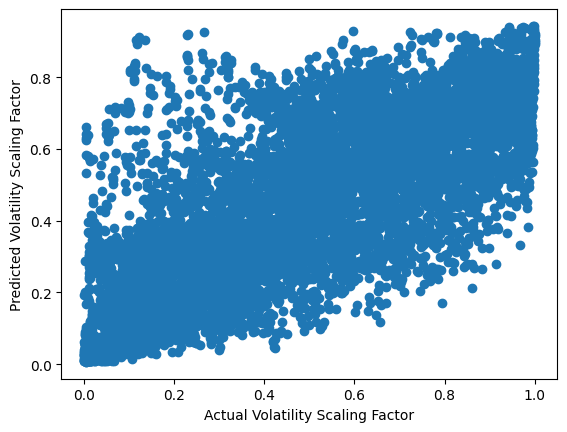

GLD


  0%|          | 0/5141 [00:00<?, ?it/s]

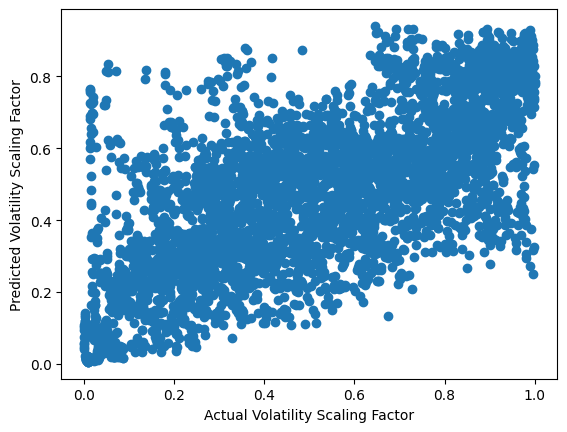

TLT


  0%|          | 0/5723 [00:00<?, ?it/s]

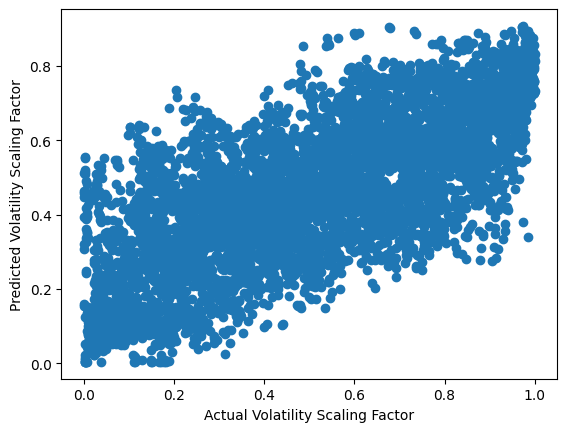

In [48]:
for ticker in assets:
    print(ticker)

    assets[ticker].process_data()
    # display(assets[ticker].data)

## Test Individual Strategy

### Vol Scaling Strategy

In [49]:
from strategies.base import BaseStrategy

class VolScaling(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('df_vol', dict()),
        ('vol_scaling_col', 'vol_scaling_percentile'),
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0
        # Vol scaling
        self.df_vol = self.p.df_vol
            
        if self.p.vol_scaling_col not in self.df_vol.columns:
            raise ValueError(f"df_vol must have column {self.p.vol_scaling_col}")
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            current_date = self.datetime.date()
            vol_scaling_factor = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), self.p.vol_scaling_col].values[0]
            target_position = vol_scaling_factor * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        
        self.rebalance_day += 1



for ticker in assets:
    df = assets[ticker].data.copy()
    # print(df.columns)
    df = df[['open', 'high', 'low', 'close', 'adjclose', 'volume', 'dividends', 'vol_scaling_factor_pred']]
    df.dropna(inplace=True)
    
    btr = BackTester({ticker: df})
    btr.add_strategy(
        VolScaling,
        tickers=[ticker],
        price_data={ticker: df},
        rebalance_period=rebalance_period,
        df_vol=df,
        vol_scaling_col='vol_scaling_factor_pred',
    )
    results = btr.backtest()
    # btr.plot_results()
    for key in results:
        if key == 'returns': continue
        print(f"{key}: {results[key]:.2f}")
    
    display(results['returns'].tail())

    assets[ticker].strategy_returns['VolScaling'] = results['returns']



cagr: 0.04
volatility: 0.06
sharpe: 0.68
max_drawdown: 0.17
cumulative_returns: 3.01


,returns
date,
2025-04-21,-0.001092
2025-04-22,0.001166
2025-04-23,0.000712
2025-04-24,0.000981
2025-04-25,0.000344


cagr: 0.05
volatility: 0.07
sharpe: 0.67
max_drawdown: 0.25
cumulative_returns: 1.17


,returns
date,
2025-04-21,0.007116
2025-04-22,-0.003343
2025-04-23,-0.005585
2025-04-24,0.003327
2025-04-25,-0.002506


cagr: 0.03
volatility: 0.06
sharpe: 0.44
max_drawdown: 0.16
cumulative_returns: 0.76


,returns
date,
2025-04-21,-0.001390
2025-04-22,0.000437
2025-04-23,0.000764
2025-04-24,0.000836
2025-04-25,0.000590


### Trend Following Strategy

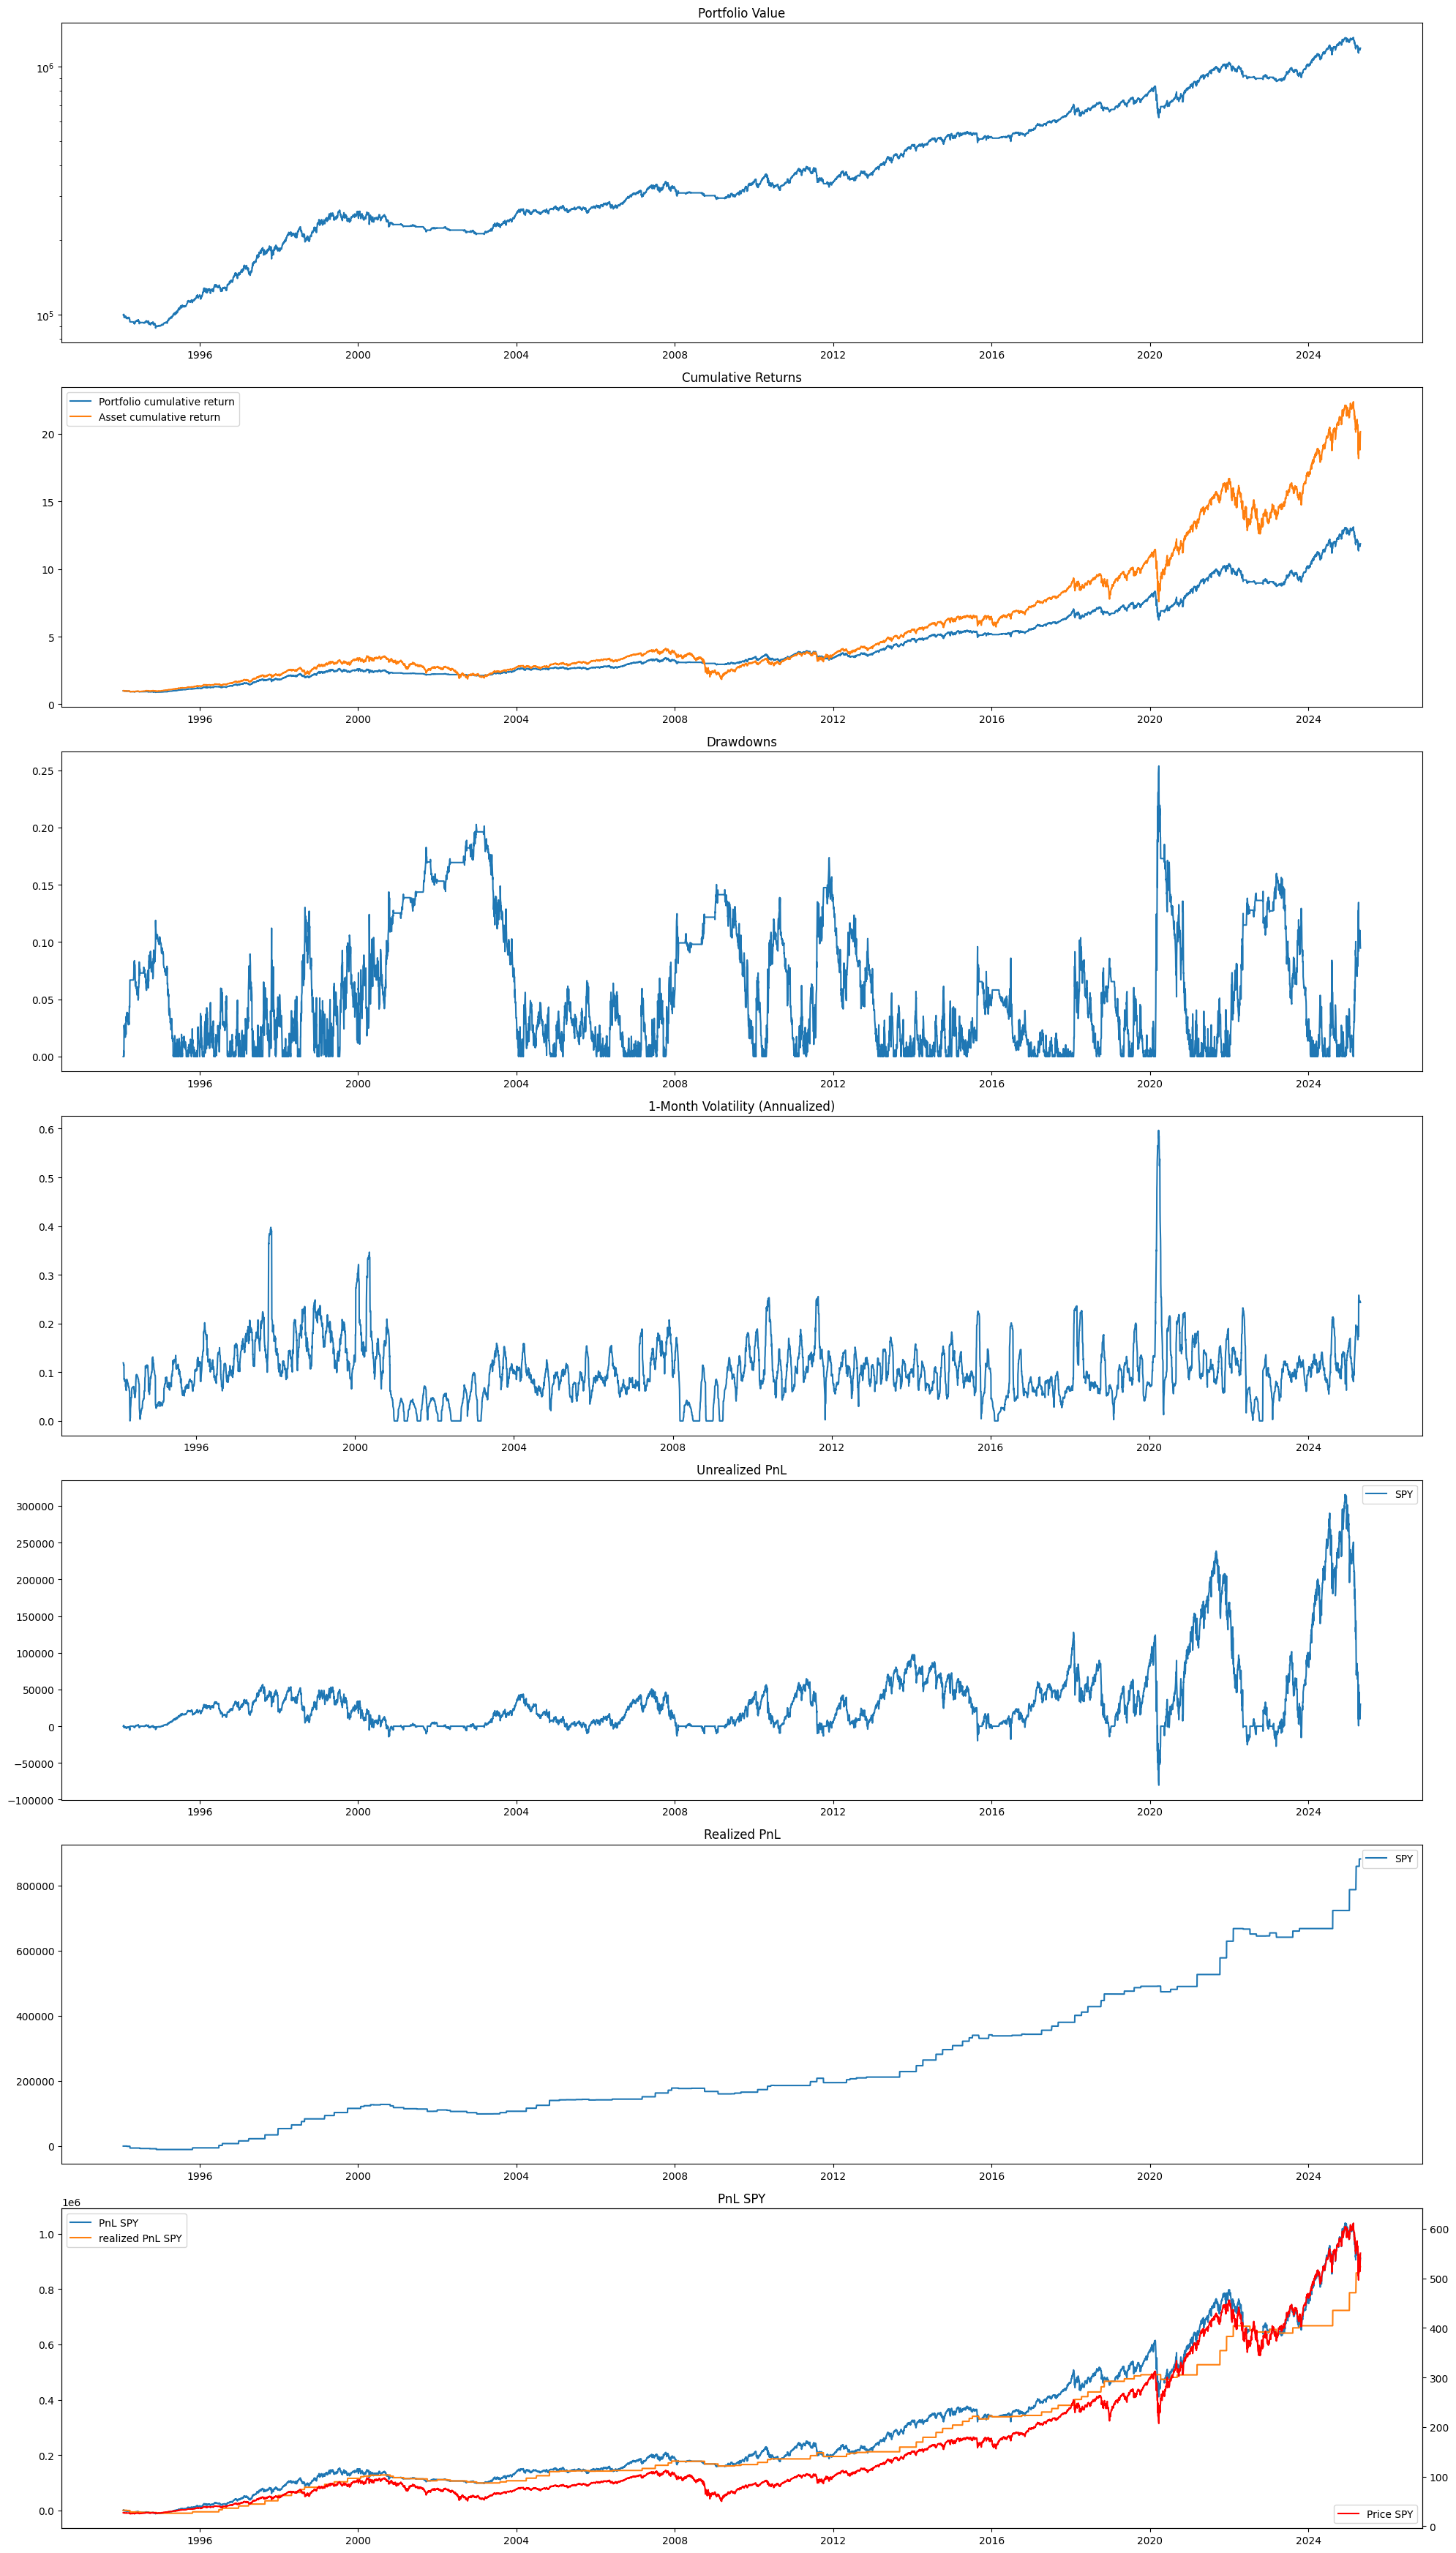

cagr: 0.08
volatility: 0.12
sharpe: 0.69
max_drawdown: 0.25
cumulative_returns: 10.87


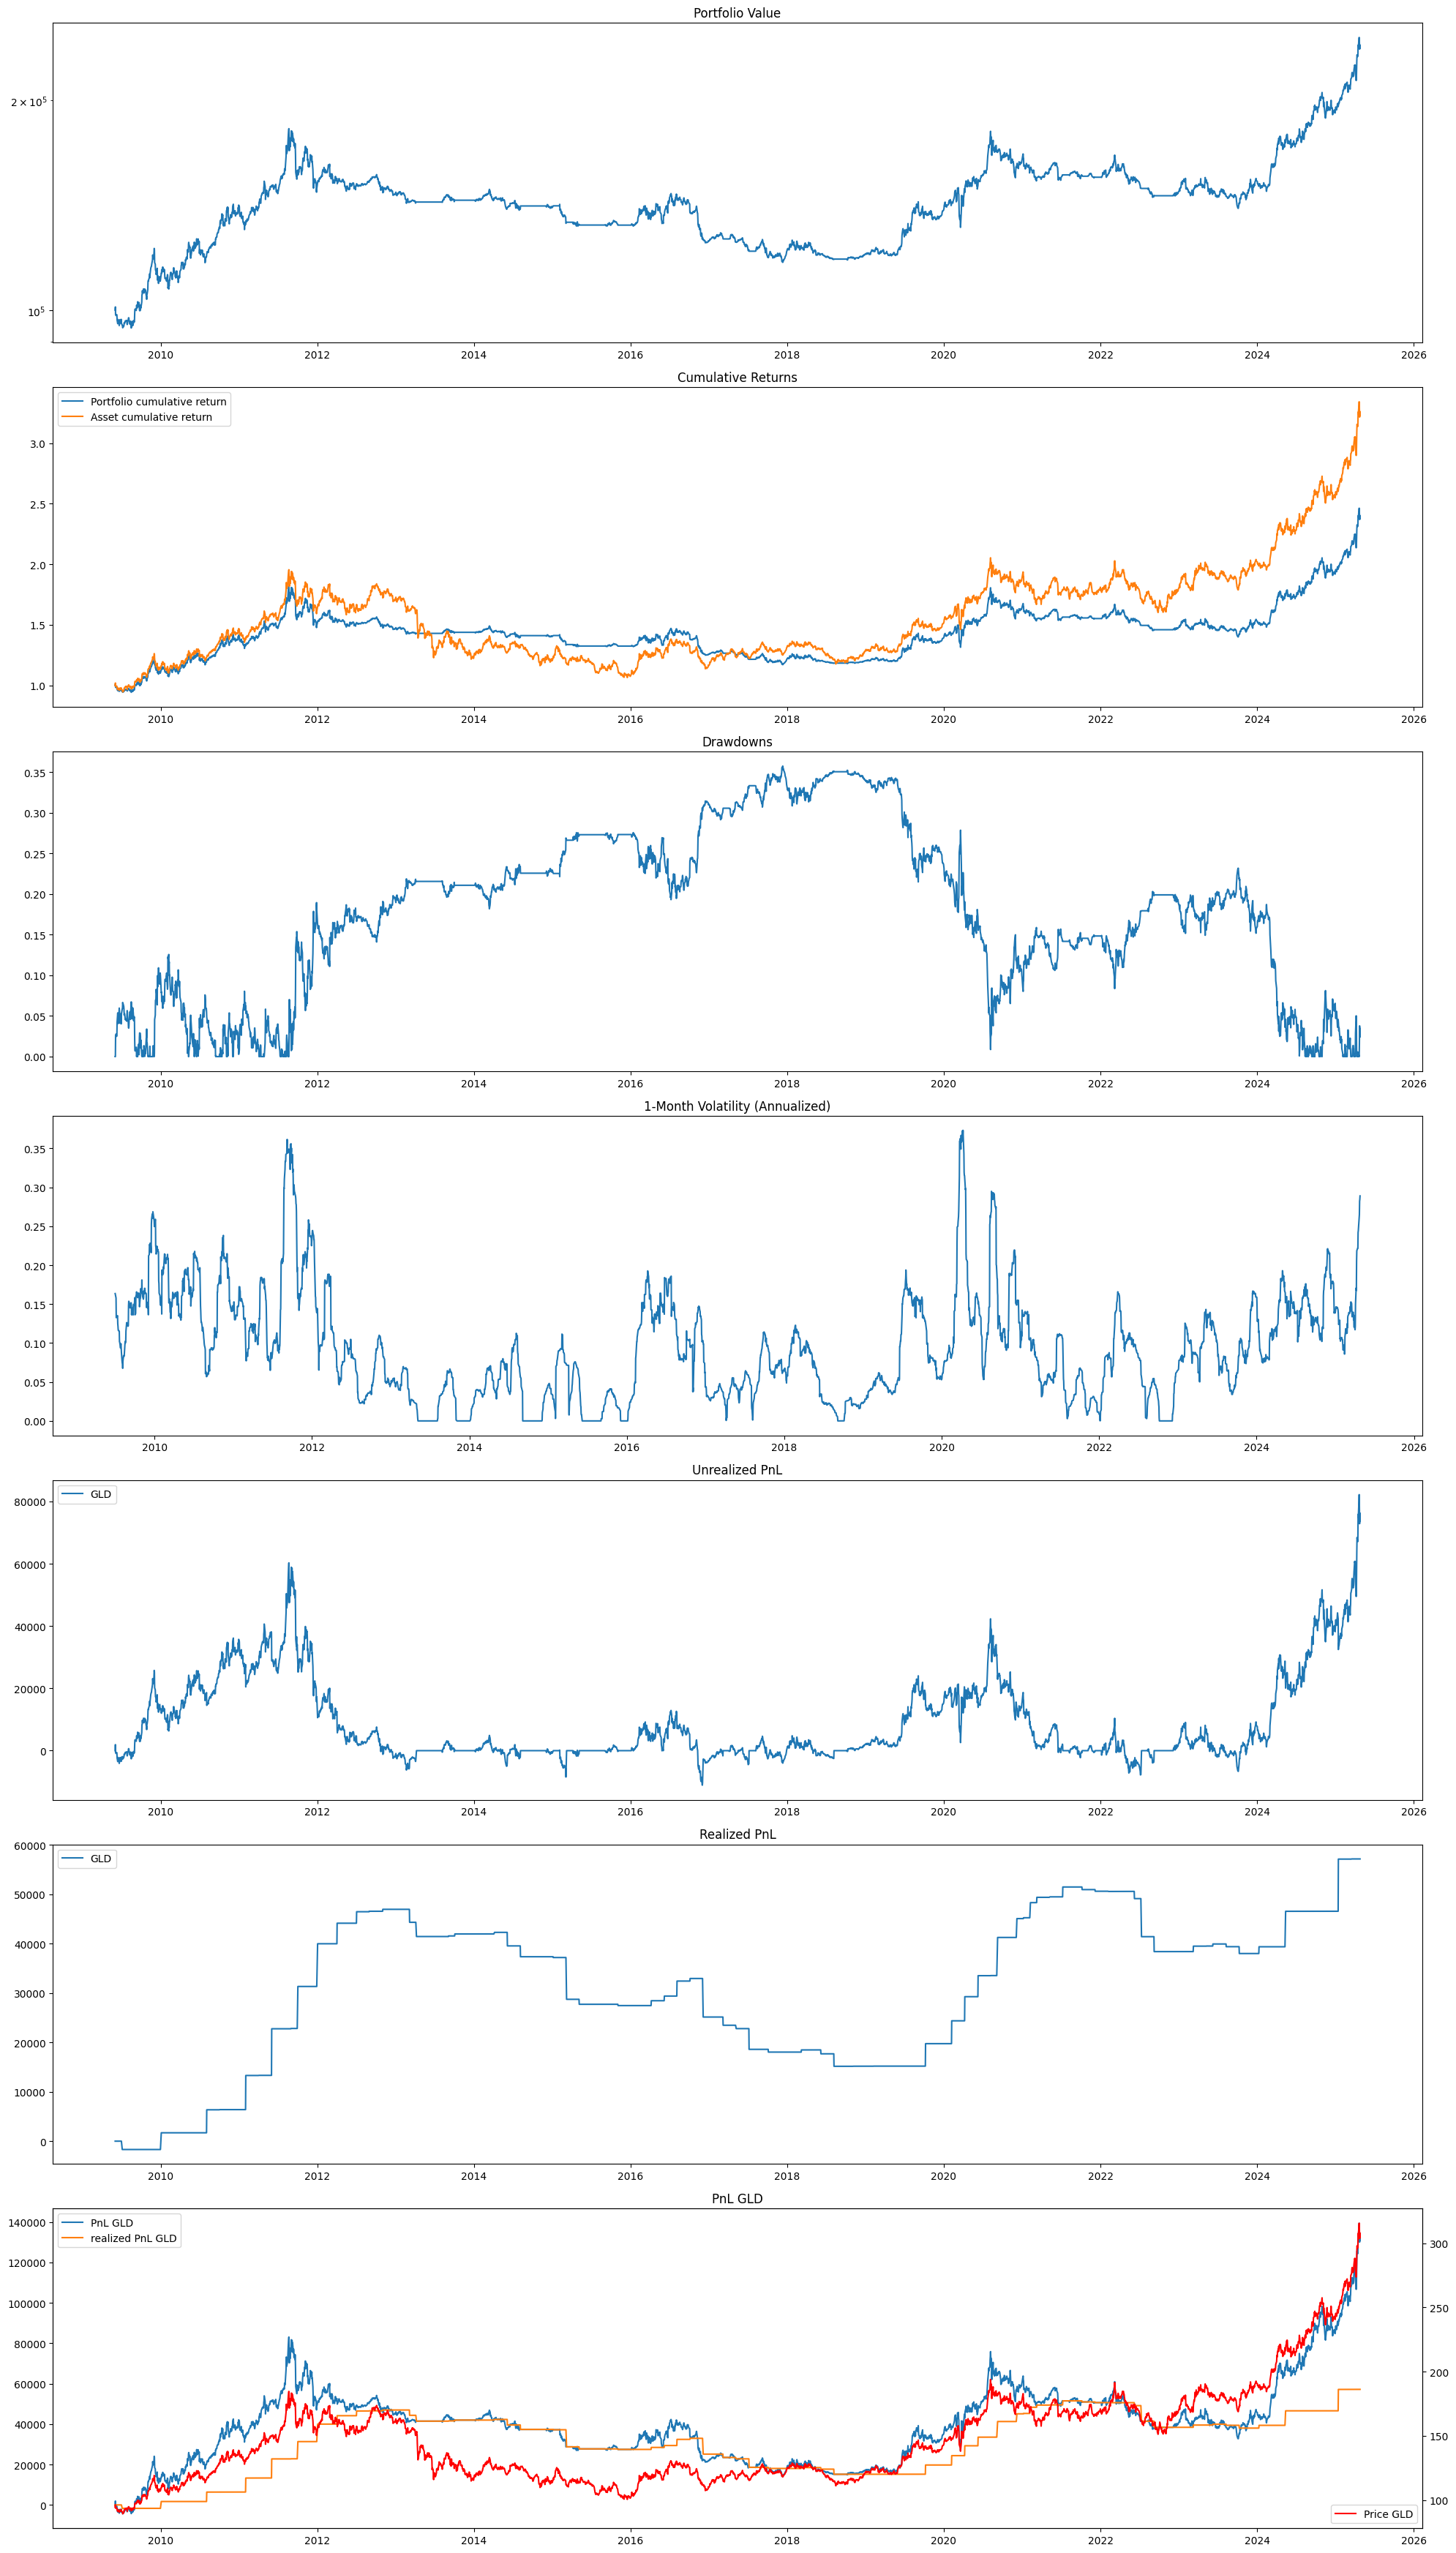

cagr: 0.06
volatility: 0.12
sharpe: 0.49
max_drawdown: 0.36
cumulative_returns: 1.38


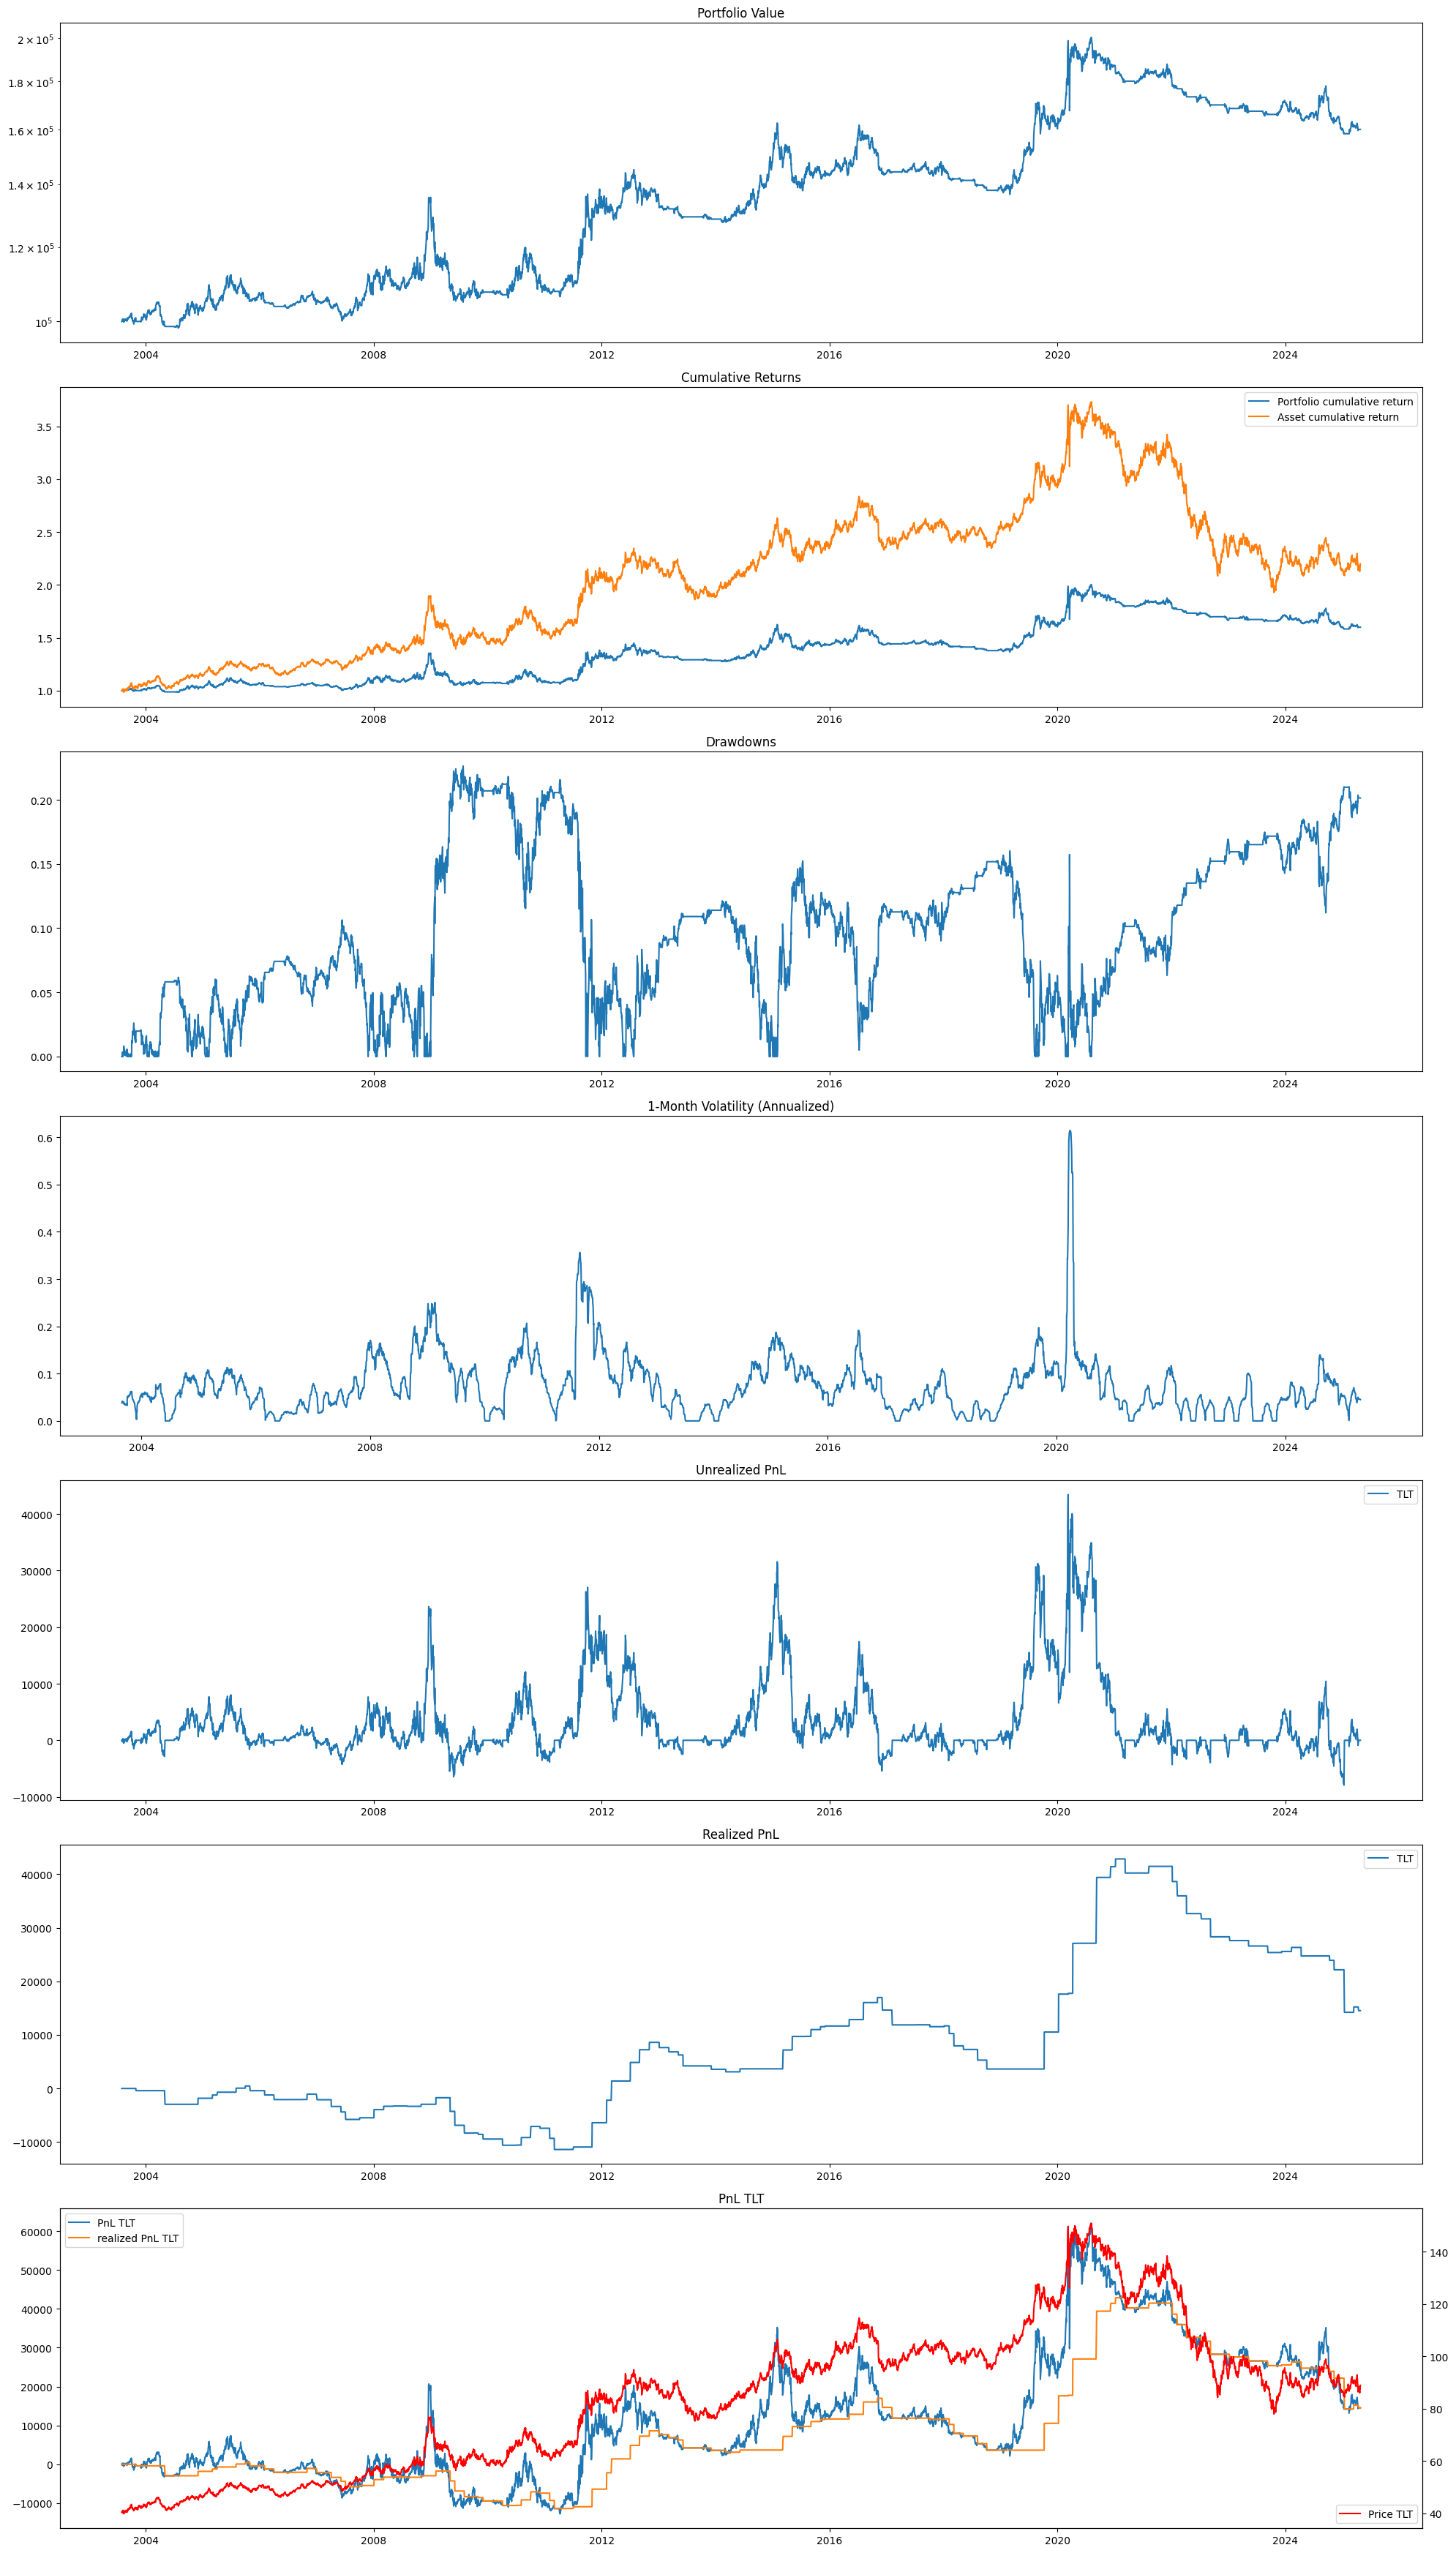

cagr: 0.02
volatility: 0.10
sharpe: 0.23
max_drawdown: 0.23
cumulative_returns: 0.60


In [ ]:
from strategies.base import BaseStrategy

class TrendFollowing(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('lookback_periods', [21, 100, 200, 252]),
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0

        # Trend identification
        self.trend = dict()
        self.lookback_weights = {}
        for period in self.p.lookback_periods:
            self.trend[period] = bt.indicators.PercentChange(self.data.close, period=period)
            self.lookback_weights[period] = 1 / len(self.p.lookback_periods)
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            trend_factor = 0.0
            for period in self.p.lookback_periods:
                if self.trend[period][0] > 0:
                    trend_factor += self.lookback_weights[period]
            target_position = trend_factor * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        
        self.rebalance_day += 1



for ticker in assets:
    df = assets[ticker].data.copy()
    # print(df.columns)
    df = df[['open', 'high', 'low', 'close', 'adjclose', 'volume', 'dividends', 'vol_scaling_factor_pred']]
    df.dropna(inplace=True)
    
    btr = BackTester({ticker: df})
    btr.add_strategy(
        TrendFollowing,
        tickers=[ticker],
        price_data={ticker: df},
        rebalance_period=rebalance_period,
        lookback_periods=[21, 100, 200, 252],
        # vol_scaling_col='vol_scaling_factor_pred',
    )
    results = btr.backtest()
    btr.plot_results()
    for key in results:
        if key == 'returns': continue
        print(f"{key}: {results[key]:.2f}")
    
    # display(results['returns'].tail())

    assets[ticker].strategy_returns['TrendFollowing'] = results['returns']



### Trend Vol

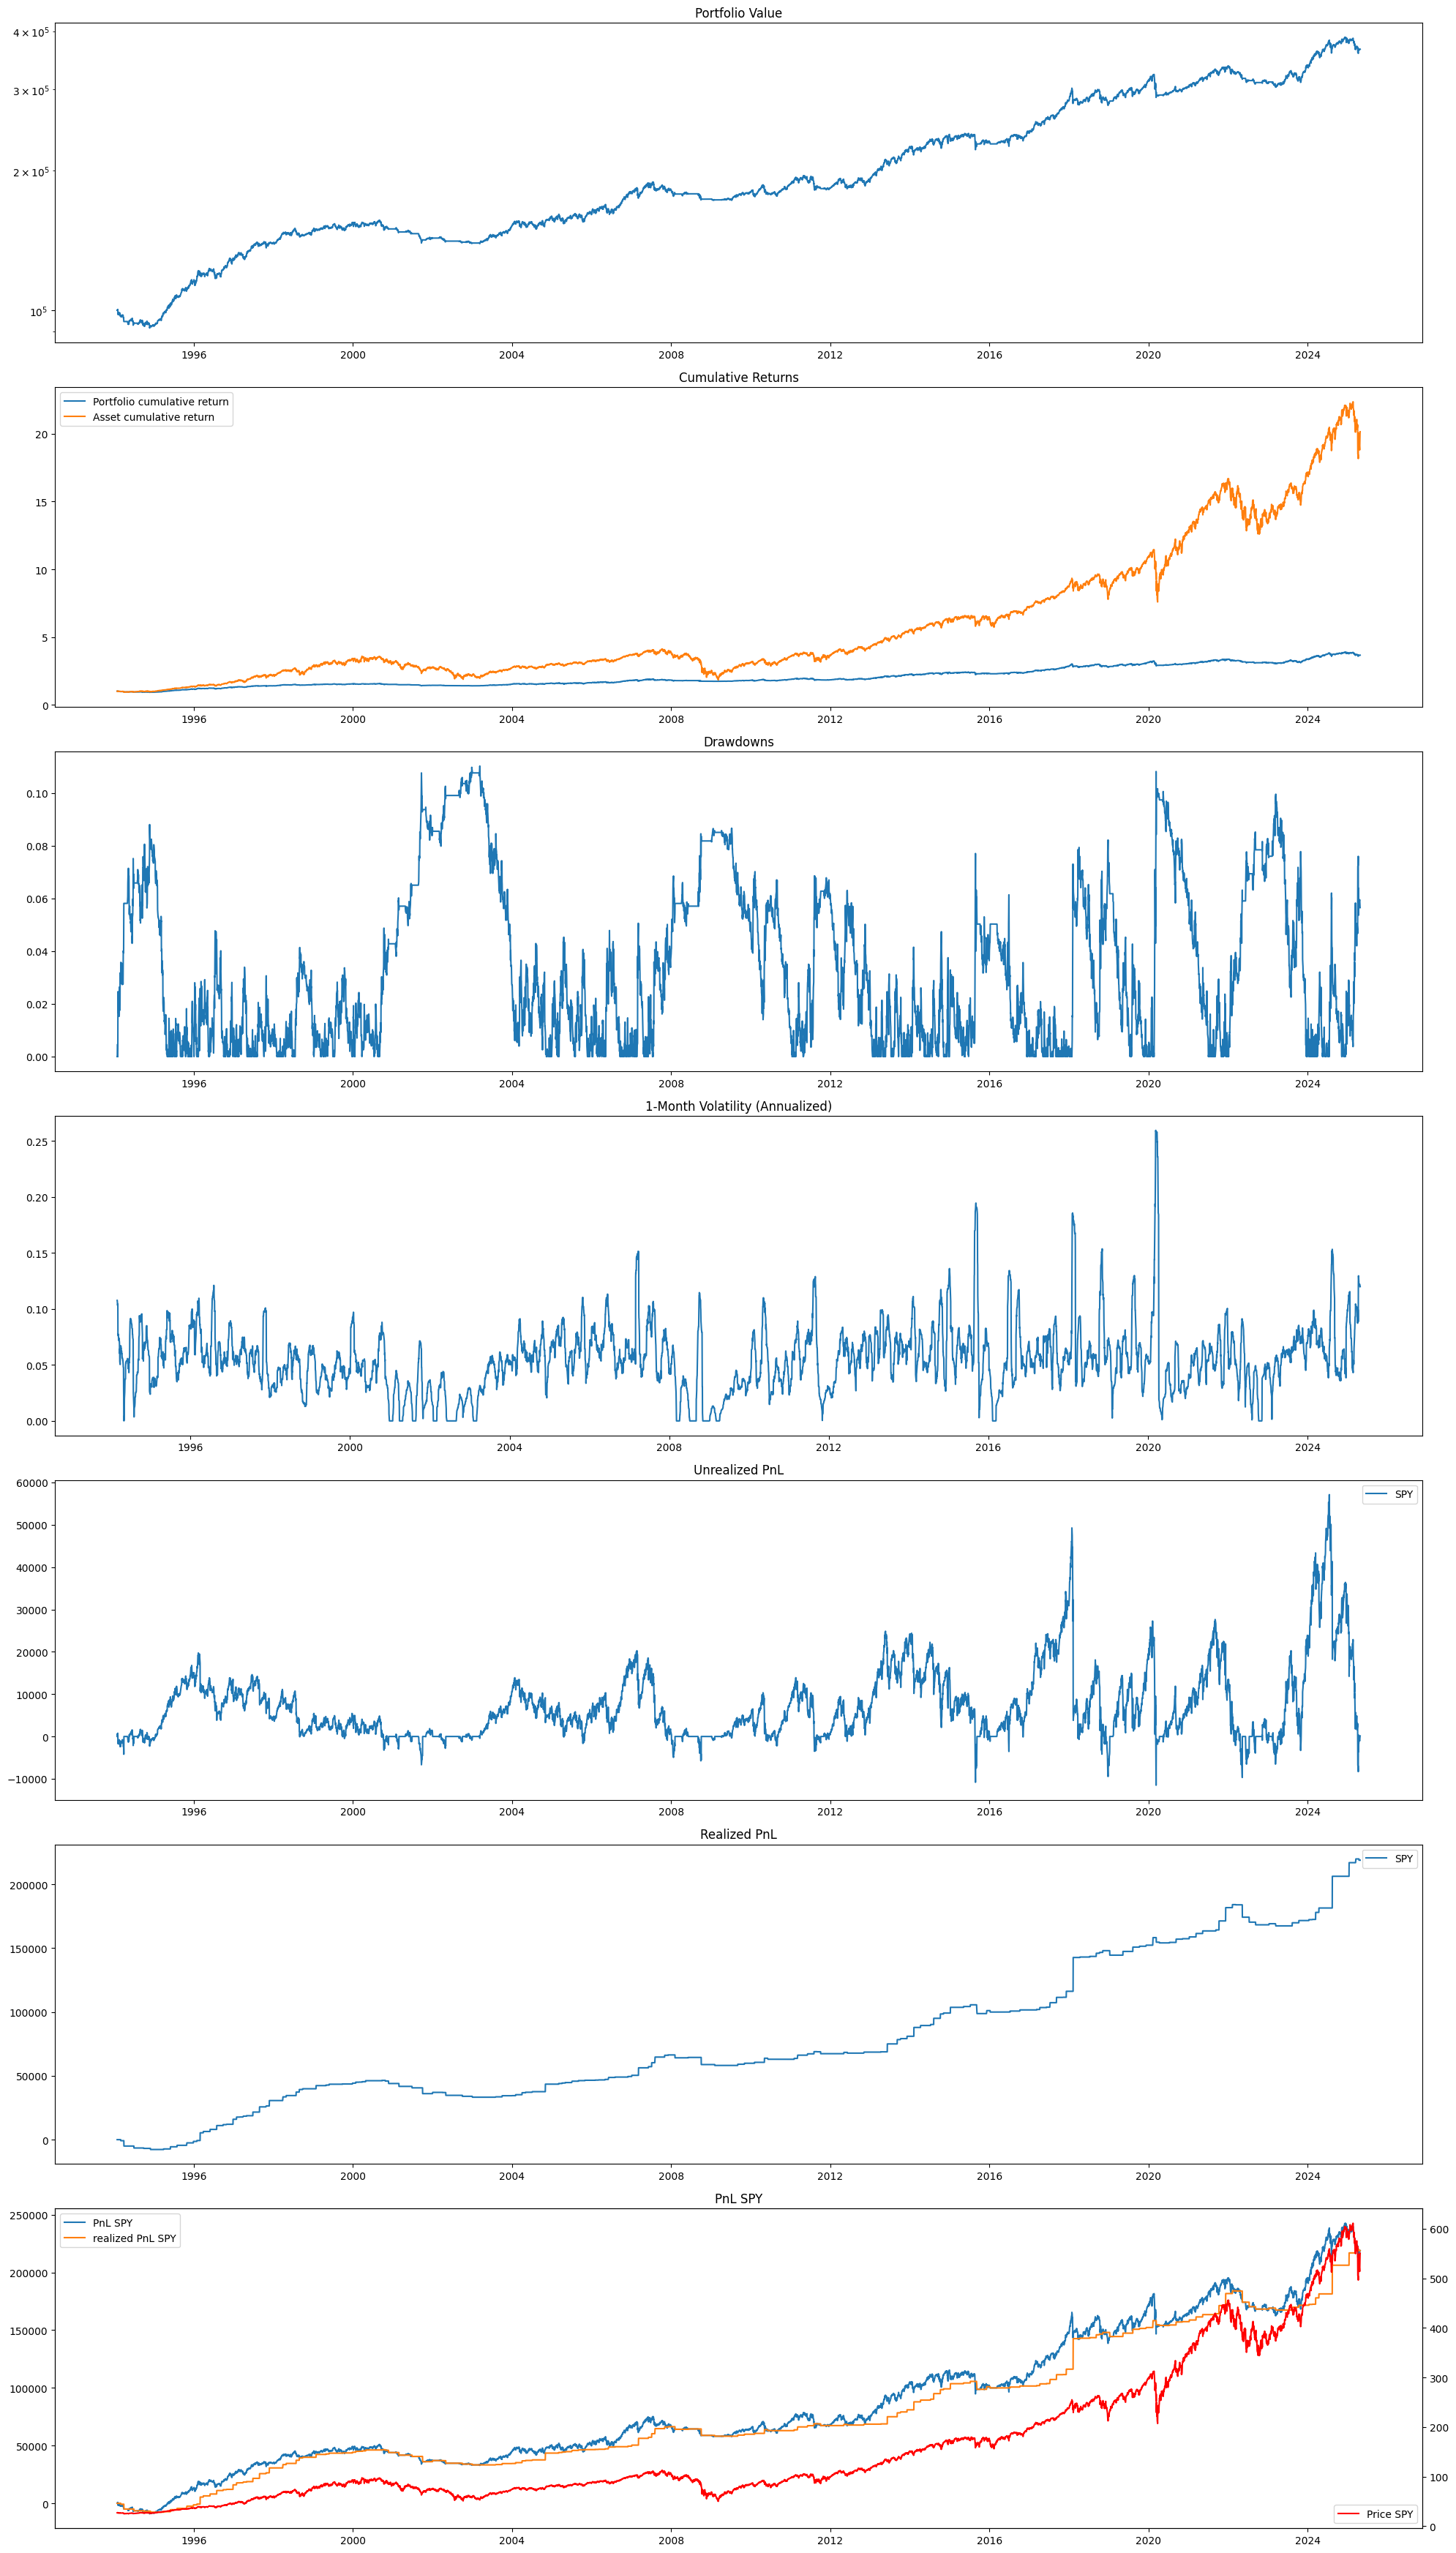

cagr: 0.04
volatility: 0.06
sharpe: 0.68
max_drawdown: 0.11
cumulative_returns: 2.66


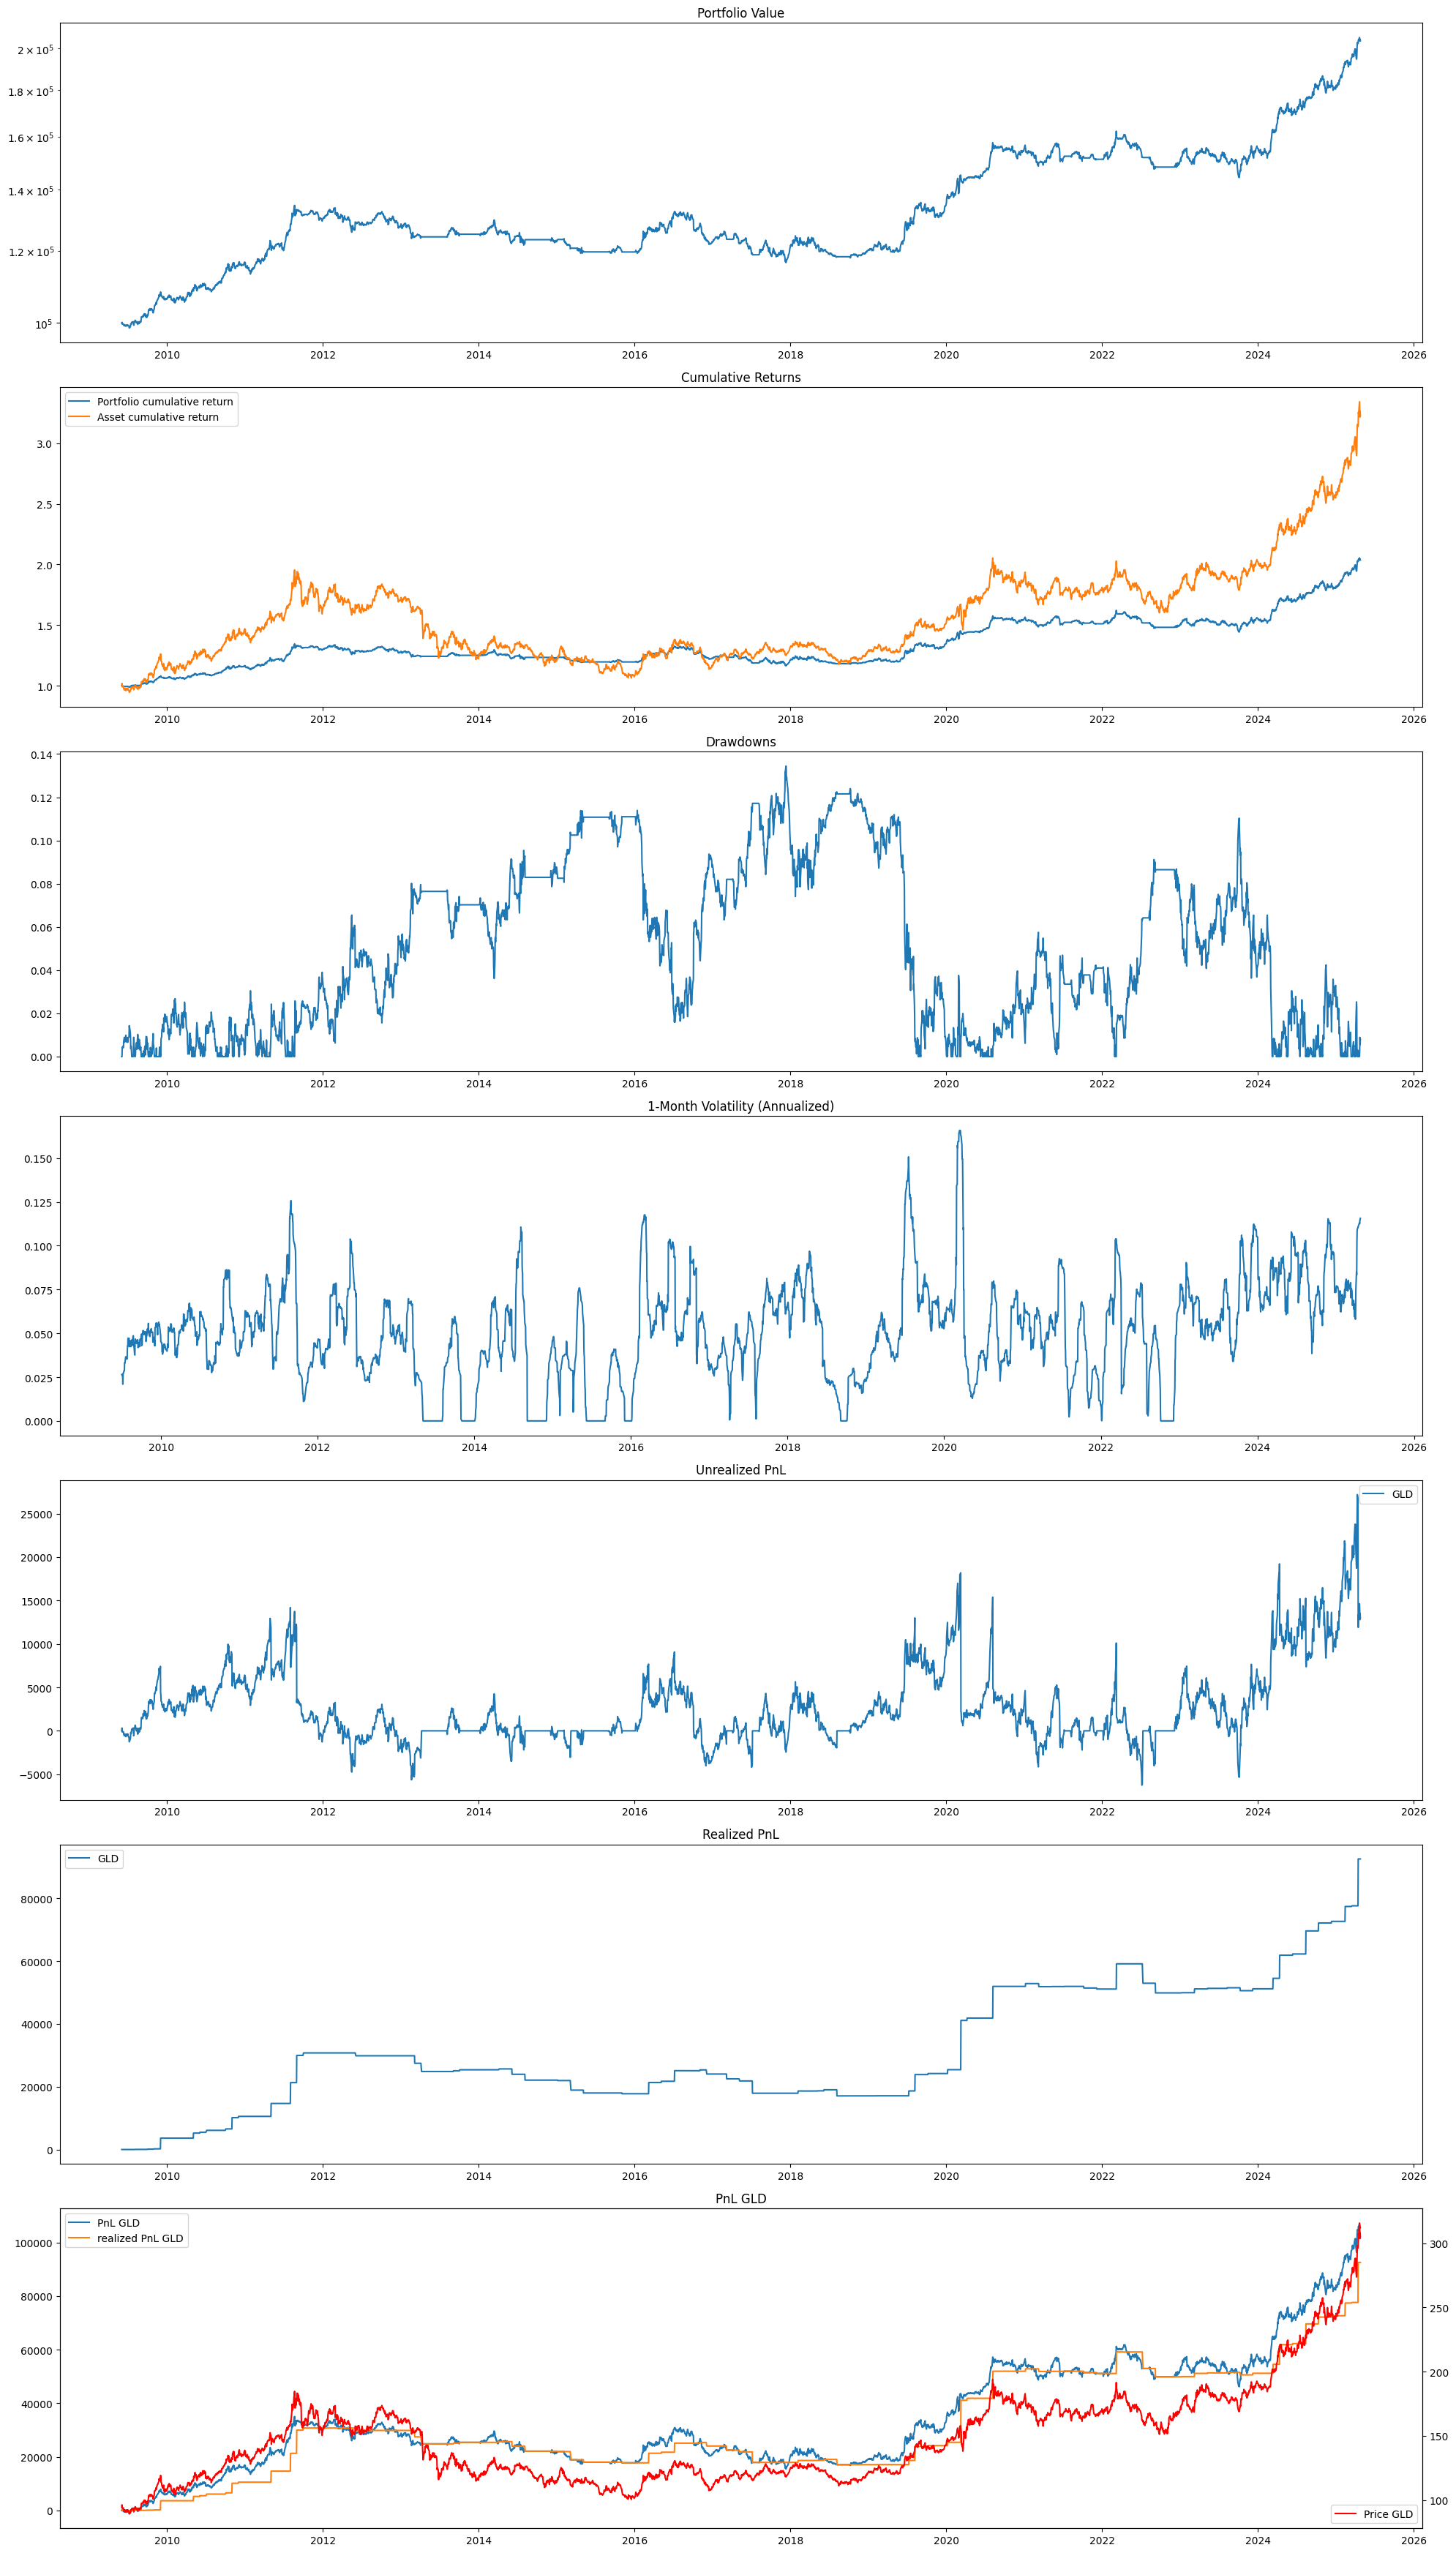

cagr: 0.05
volatility: 0.06
sharpe: 0.78
max_drawdown: 0.13
cumulative_returns: 1.04


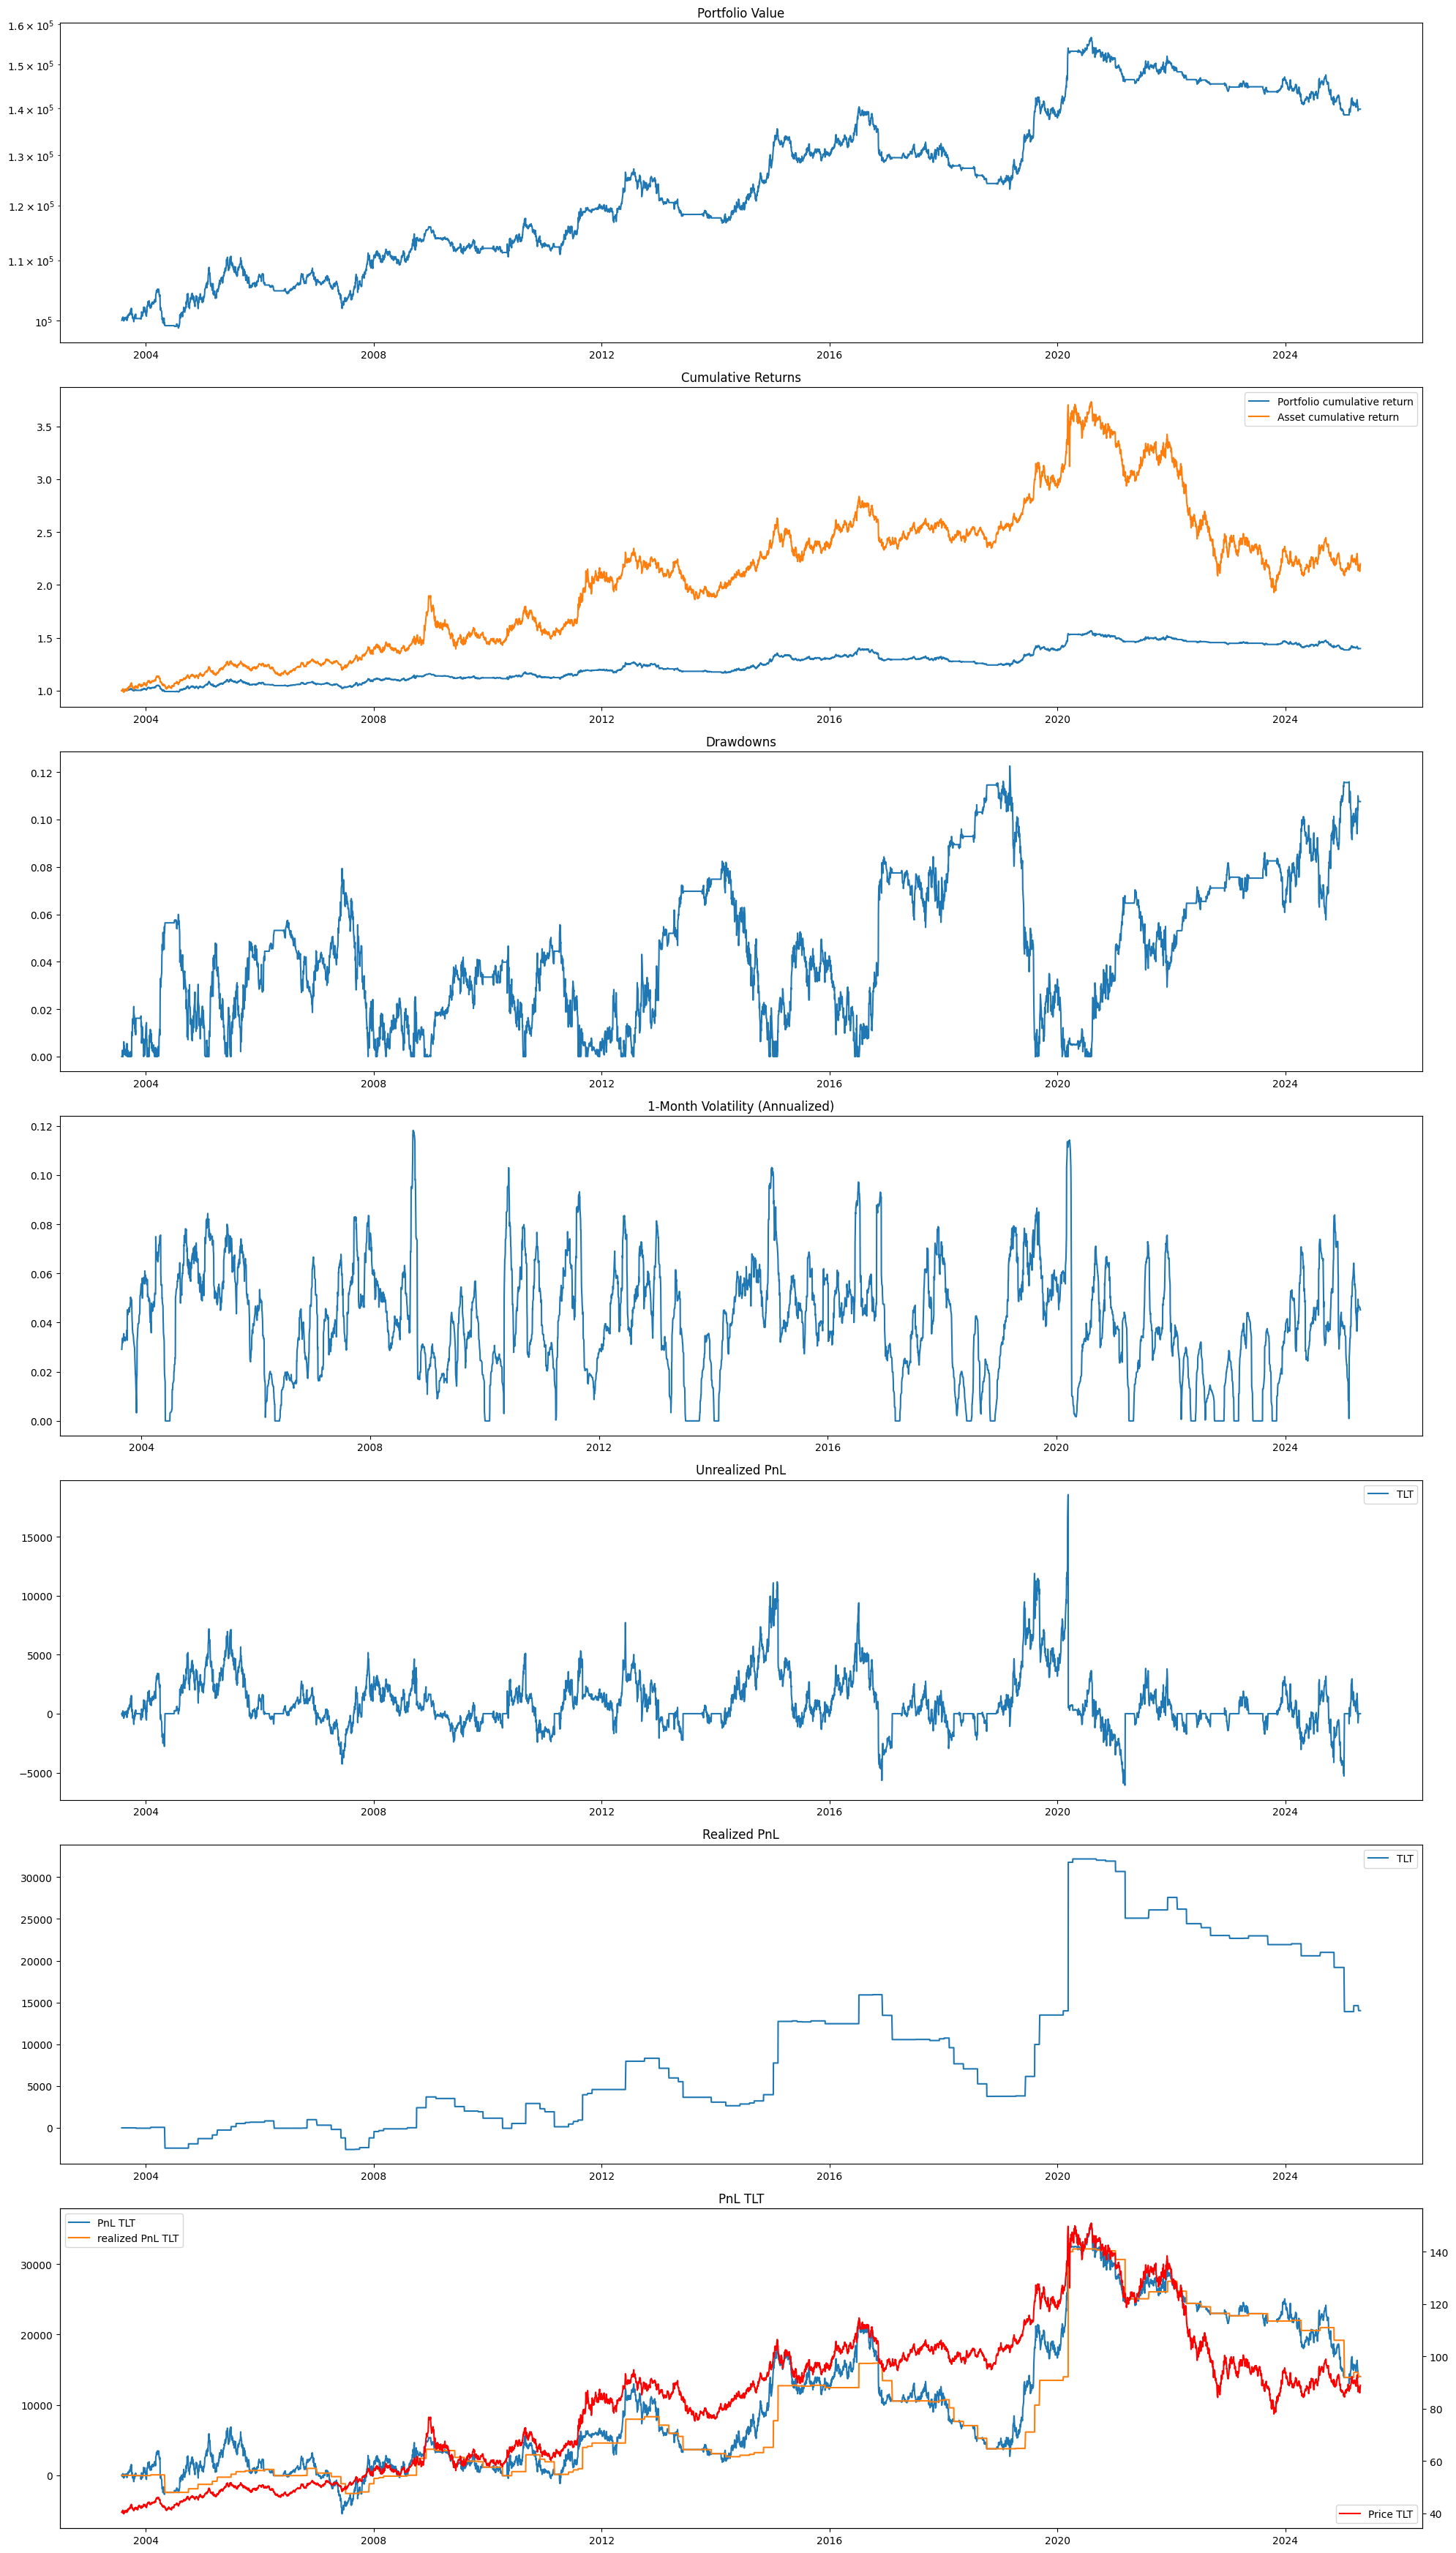

cagr: 0.02
volatility: 0.05
sharpe: 0.34
max_drawdown: 0.12
cumulative_returns: 0.40


In [63]:
from strategies.base import BaseStrategy

class TrendVol(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('lookback_periods', [21, 100, 200, 252]),
        ('df_vol', dict()),
        ('vol_scaling_col', 'vol_scaling_percentile'),
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0

        # Trend identification
        self.trend = dict()
        self.lookback_weights = {}
        for period in self.p.lookback_periods:
            self.trend[period] = bt.indicators.PercentChange(self.data.close, period=period)
            self.lookback_weights[period] = 1 / len(self.p.lookback_periods)

        # Vol scaling
        self.df_vol = self.p.df_vol
        if self.p.vol_scaling_col not in self.df_vol.columns:
            raise ValueError(f"df_vol must have column {self.p.vol_scaling_col}")
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            current_date = self.datetime.date()

            # Trend factor
            trend_factor = 0.0
            for period in self.p.lookback_periods:
                if self.trend[period][0] > 0:
                    trend_factor += self.lookback_weights[period]
            
            # Vol scaling factor
            vol_scaling_factor = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), self.p.vol_scaling_col].values[0]
            
            target_position = np.min([trend_factor, vol_scaling_factor]) * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        
        self.rebalance_day += 1



for ticker in assets:
    df = assets[ticker].data.copy()
    # print(df.columns)
    df = df[['open', 'high', 'low', 'close', 'adjclose', 'volume', 'dividends', 'vol_scaling_factor_pred']]
    df.dropna(inplace=True)
    
    btr = BackTester({ticker: df})
    btr.add_strategy(
        TrendVol,
        tickers=[ticker],
        price_data={ticker: df},
        rebalance_period=rebalance_period,
        lookback_periods=[21, 100, 200, 252],
        df_vol=df,
        vol_scaling_col='vol_scaling_factor_pred',
    )
    results = btr.backtest()
    btr.plot_results()
    for key in results:
        if key == 'returns': continue
        print(f"{key}: {results[key]:.2f}")
    
    # display(results['returns'].tail())

    assets[ticker].strategy_returns['TrendVol'] = results['returns']

## Combining with HRP

SPY TrendVol
GLD TrendVol
TLT TrendVol
              SPY_TrendVol  GLD_TrendVol  TLT_TrendVol
SPY_TrendVol      0.009861      0.002971      0.000309
GLD_TrendVol      0.002971      0.008941     -0.000037
TLT_TrendVol      0.000309     -0.000037      0.001885
OrderedDict({'GLD_TrendVol': np.float64(0.12272409822355258), 'SPY_TrendVol': np.float64(0.1112713305761288), 'TLT_TrendVol': np.float64(0.7660045712003186)})
Annual volatility: 3.9%


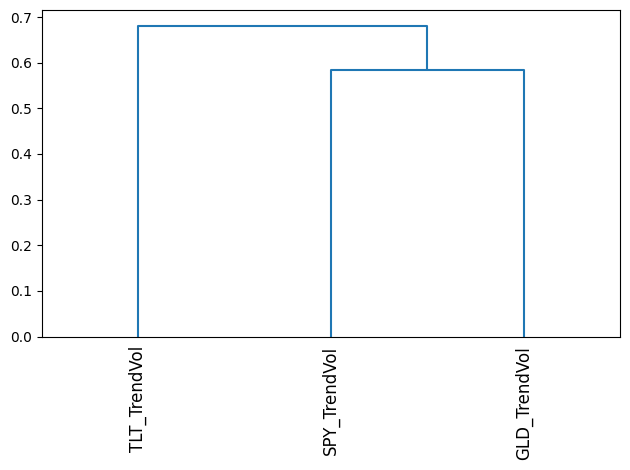

In [71]:
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models




def normalize_weights(weights):
    total_weight = sum(weights.values())
    normalized_weights = {ticker: weight / total_weight for ticker, weight in weights.items()}
    return normalized_weights



df_combined_returns = []
for ticker in assets:
    for strat in assets[ticker].strategy_returns:
        if strat != 'TrendVol':
            continue
        print(ticker, strat)
        ticker_strat = f"{ticker}_{strat}"
        s = assets[ticker].strategy_returns[strat]['returns'].rename(ticker_strat)
        df_combined_returns.append(s)
df_combined_returns = pd.concat(df_combined_returns, axis=1, join='inner')
ewma_cov = risk_models.exp_cov(df_combined_returns, returns_data=True, span=60)
print(ewma_cov)

hrpopt = HRPOpt(
    # returns=df_combined_returns, 
    cov_matrix=ewma_cov
)
weights = hrpopt.optimize()
print(weights)
hrpopt.portfolio_performance(verbose=True)
plot_dendrogram(hrpopt)
plt.show()

# c = 0
# weights_list = []
# for i, r in tqdm(df_combined_returns.iterrows(), total=len(df_combined_returns)):
#     df_ = df_combined_returns.loc[
#         (df_combined_returns.index <= i) &
#         (df_combined_returns.index >= i - pd.Timedelta(days=252*2))
#     ]

#     weights = {f: 1 for f in df_combined_returns.columns}
#     weights = normalize_weights(weights)
    
#     if c > 21:
#         hrp_opt = HRPOpt(returns=df_)
#         weights = hrp_opt.optimize()
    
#     weights_list.append(weights)
    
#     c += 1

# df_combined_returns
# df_weights = df_combined_returns.copy()
# df_weights['weights'] = weights_list
# df_weights = df_weights[['weights']]
# df_weights

# class DynamicAllocation(BaseStrategy):

#     params = (
#         ('rebalance_period', 21),
#         ('df_weights', pd.DataFrame()),
#     )

#     def __init__(self):
#         super().__init__()
#         self.rebalance_day = 0
#         self.df_weights = self.p.df_weights
        
#     def next(self):
#         super().next()
#         if self.rebalance_day % self.p.rebalance_period == 0:
#             current_capital = self.broker.getvalue()
#             current_date = pd.to_datetime(self.datetime.date())
            
#             current_weights = self.df_weights.loc[self.df_weights.index == current_date]
#             if current_weights.shape[0] == 0:
#                 current_weights = {f: 1 for f in self.p.tickers}
#             else:
#                 current_weights = current_weights['weights'].to_list()[0]
            

#             for ticker in self.p.tickers:
#                 data = self.getdatabyname(ticker)
#                 current_position = self.broker.getposition(data).size
#                 ticker_capital = current_capital * current_weights[ticker]
                
#                 target_position = ticker_capital / self.data.close[0]
#                 # Submit order
#                 self._submit_order(ticker, target_position - current_position, self.data.close[0])
#         self.rebalance_day += 1



# btr = BackTester(asset_dfs)
# btr.add_strategy(
#     DynamicAllocation, 
#     tickers=asset_dfs.keys(), 
#     price_data=asset_dfs, 
#     rebalance_period=rebalance_period, 
#     df_weights=df_returns,
# )
# results = btr.backtest()
# if verbose:
#     btr.plot_results()
#     for key in results:
#         if key == 'returns': continue
#         print(f"{key}: {results[key]:.2f}")

